# BIG WIP

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from helper_functions import safe_wkt_load, quick_px_scattermap
import osmnx as ox
import networkx as nx
from sklearn.cluster import DBSCAN
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

In [2]:
station_avg_delay = pd.read_csv("../data/processed/cleaned_delay_data.csv")
station_avg_ridership = pd.read_csv("../data/processed/selected_station_ridership.csv")
selected_routes_shapes = pd.read_csv("../data/processed/selected_routes.csv")
sj_adt = pd.read_csv("../data/processed/selected_sj_adt.csv")

# Join Avg. Delay and Avg. Ridership Tables

In [3]:
selected_routes = ['22', 'Rapid 522', '23', 'Rapid 523', '25', '60']
station_avg_delay = station_avg_delay[station_avg_delay["route_id"].isin(selected_routes)]
station_avg_delay = station_avg_delay.groupby(['route_id', 'direction_id', 'stop_id', 'stop_sequence']).agg(mean_delay=("computed_delay_sec", "mean")).reset_index().sort_values(['route_id', 'direction_id', 'stop_sequence'])
station_avg_delay["route_id"] = station_avg_delay["route_id"].str.replace(
    r"^Rapid\s+", "", regex=True
).astype(int)
station_avg_delay

,route_id,direction_id,stop_id,stop_sequence,mean_delay
18,22,0,60328,2,139.500000
19,22,0,60329,3,196.000000
20,22,0,60330,4,173.000000
21,22,0,60331,5,146.500000
22,22,0,60332,6,158.666667
...,...,...,...,...,...
586,523,1,60651,13,-466.000000
587,523,1,60653,14,-488.500000
588,523,1,60656,15,-525.000000
589,523,1,60660,16,-604.500000


In [4]:
station_avg_ridership['direction_id'] = station_avg_ridership['direction_id'] % 10
station_avg_ridership = station_avg_ridership.sort_values(['route_id', 'direction_id', 'stop_id'])
station_avg_ridership

,route_id,direction_id,stop_id,stop_name,boardings,alightings,total_b_a,geometry
0,22,0,60001,Santa Clara Transit Center,152.880022,110.852250,263.732272,POINT (6144099.62758 1954225.5200159)
4,22,0,60020,El Camino & Lafayette,40.890986,57.438087,98.329073,POINT (6141651.00288408 1954992.24617273)
6,22,0,60035,King & Alum Rock,149.607974,157.936236,307.544210,POINT (6167727.93202934 1953654.17929506)
7,22,0,60036,King & San Antonio,36.418456,38.469837,74.888293,POINT (6168552.89461824 1952565.84026439)
8,22,0,60037,King & Hermocilla,31.495157,45.198273,76.693430,POINT (6169311.51383591 1951509.07203673)
...,...,...,...,...,...,...,...,...
586,523,1,64478,Lockheed Martin Transit Center,0.000000,317.466630,317.466630,POINT (6117801.90097608 1975568.38743506)
601,523,1,64696,Stevens Creek & Winchester,85.577443,90.755989,176.333432,POINT (6139677.16759291 1943518.2914304)
620,523,1,65741,Stevens Creek & Valley Fair / Santana Row,109.060532,391.806776,500.867308,POINT (6141126.594156 1943538.09191573)
642,523,1,65902,Sunnyvale-Saratoga & El Camino,189.107898,219.736022,408.843920,POINT (6116423.22131875 1959757.18710214)


In [5]:
stations_df = pd.merge(station_avg_delay, station_avg_ridership, on=['route_id', 'direction_id', 'stop_id'], how='inner')
stations_df["geometry"] = stations_df["geometry"].apply(safe_wkt_load)
stations_gdf = gpd.GeoDataFrame(stations_df, geometry='geometry', crs="EPSG:2227").sort_values(["route_id", "direction_id", "stop_sequence"])
stations_gdf

,route_id,direction_id,stop_id,stop_sequence,mean_delay,stop_name,boardings,alightings,total_b_a,geometry
0,22,0,60328,2,139.500000,Palo Alto Transit Center (Bay 10),733.994859,0.238095,734.176677,POINT (6078107.96 1988346.454)
1,22,0,60329,3,196.000000,El Camino & Palm,12.793264,3.426027,16.219290,POINT (6079055.872 1986640.972)
2,22,0,60330,4,173.000000,El Camino & Galvez,66.459791,7.428228,73.888019,POINT (6079788.226 1985807.876)
3,22,0,60331,5,146.500000,El Camino & Sam McDonald,4.579660,0.262500,4.842160,POINT (6080518.117 1984980.671)
4,22,0,60332,6,158.666667,El Camino & Churchill,4.251791,1.055649,5.307440,POINT (6081284.46 1984093.848)
...,...,...,...,...,...,...,...,...,...,...
568,523,1,60646,12,-410.000000,Stevens Creek & Kiely,131.524218,172.415548,303.939766,POINT (6132531.454 1943566.328)
569,523,1,60651,13,-466.000000,Stevens Creek & Cabot,52.817891,62.395022,115.212913,POINT (6127904.459 1943613.843)
570,523,1,60656,15,-525.000000,Stevens Creek & Wolfe,66.990445,88.557801,155.548246,POINT (6121122.696 1943673.642)
571,523,1,60660,16,-604.500000,Stevens Creek & De Anza,85.345256,218.676593,304.021849,POINT (6115865.544 1943743.247)


# Determine Station Spacings

In [6]:
G = ox.graph_from_place("Santa Clara County, California, USA", network_type="drive")
G = ox.project_graph(G, to_crs="EPSG:2227")

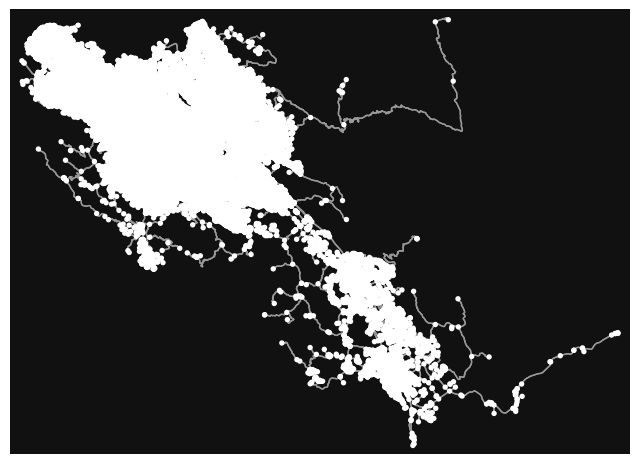

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [7]:
ox.plot_graph(G)

In [8]:
stations_gdf = stations_gdf.to_crs(G.graph["crs"])

nodes = ox.distance.nearest_nodes(
    G,
    X=stations_gdf.geometry.x,
    Y=stations_gdf.geometry.y
)

stations_gdf["node"] = nodes
stations_gdf

,route_id,direction_id,stop_id,stop_sequence,mean_delay,stop_name,boardings,alightings,total_b_a,geometry,node
0,22,0,60328,2,139.500000,Palo Alto Transit Center (Bay 10),733.994859,0.238095,734.176677,POINT (6078107.96 1988346.454),868564168
1,22,0,60329,3,196.000000,El Camino & Palm,12.793264,3.426027,16.219290,POINT (6079055.872 1986640.972),6067350538
2,22,0,60330,4,173.000000,El Camino & Galvez,66.459791,7.428228,73.888019,POINT (6079788.226 1985807.876),1819712513
3,22,0,60331,5,146.500000,El Camino & Sam McDonald,4.579660,0.262500,4.842160,POINT (6080518.117 1984980.671),65518519
4,22,0,60332,6,158.666667,El Camino & Churchill,4.251791,1.055649,5.307440,POINT (6081284.46 1984093.848),6067033560
...,...,...,...,...,...,...,...,...,...,...,...
568,523,1,60646,12,-410.000000,Stevens Creek & Kiely,131.524218,172.415548,303.939766,POINT (6132531.454 1943566.328),2404195087
569,523,1,60651,13,-466.000000,Stevens Creek & Cabot,52.817891,62.395022,115.212913,POINT (6127904.459 1943613.843),262982776
570,523,1,60656,15,-525.000000,Stevens Creek & Wolfe,66.990445,88.557801,155.548246,POINT (6121122.696 1943673.642),306087834
571,523,1,60660,16,-604.500000,Stevens Creek & De Anza,85.345256,218.676593,304.021849,POINT (6115865.544 1943743.247),65426566


In [9]:
def compute_osm_spacing(stations_gdf):
    results = []

    for (route_id, direction_id), stops in stations_gdf.groupby(["route_id", "direction_id"]):

        stops = stops.sort_values("stop_sequence").copy()
        spacings = [None]

        for i in range(1, len(stops)):
            n1 = stops.iloc[i - 1]["node"]
            n2 = stops.iloc[i]["node"]

            try:
                dist = nx.shortest_path_length(G, n1, n2, weight="length")
            except:
                dist = None

            spacings.append(dist)

        stops["spacing_ft"] = spacings
        results.append(stops)

    return pd.concat(results, ignore_index=True)

In [10]:
station_spacings = compute_osm_spacing(stations_gdf).dropna()
station_spacings

,route_id,direction_id,stop_id,stop_sequence,mean_delay,stop_name,boardings,alightings,total_b_a,geometry,node,spacing_ft
1,22,0,60329,3,196.000000,El Camino & Palm,12.793264,3.426027,16.219290,POINT (6079055.872 1986640.972),6067350538,697.200342
2,22,0,60330,4,173.000000,El Camino & Galvez,66.459791,7.428228,73.888019,POINT (6079788.226 1985807.876),1819712513,352.118584
3,22,0,60331,5,146.500000,El Camino & Sam McDonald,4.579660,0.262500,4.842160,POINT (6080518.117 1984980.671),65518519,372.144171
4,22,0,60332,6,158.666667,El Camino & Churchill,4.251791,1.055649,5.307440,POINT (6081284.46 1984093.848),6067033560,309.088220
5,22,0,60333,7,124.333333,El Camino & Serra,14.807891,3.132274,17.940164,POINT (6082149.768 1983118.266),6067063479,380.384955
...,...,...,...,...,...,...,...,...,...,...,...,...
568,523,1,60646,12,-410.000000,Stevens Creek & Kiely,131.524218,172.415548,303.939766,POINT (6132531.454 1943566.328),2404195087,1519.318249
569,523,1,60651,13,-466.000000,Stevens Creek & Cabot,52.817891,62.395022,115.212913,POINT (6127904.459 1943613.843),262982776,1535.552862
570,523,1,60656,15,-525.000000,Stevens Creek & Wolfe,66.990445,88.557801,155.548246,POINT (6121122.696 1943673.642),306087834,2357.018870
571,523,1,60660,16,-604.500000,Stevens Creek & De Anza,85.345256,218.676593,304.021849,POINT (6115865.544 1943743.247),65426566,1716.196417


In [11]:
fig = quick_px_scattermap(station_spacings,
                          color="spacing_ft",
                          opacity=0.5,
                          hover_data=["route_id", "direction_id", "stop_sequence", "spacing_ft", "total_b_a"],
                          zoom=10,
                          height=650
)
fig.show()

# Approximate Nearby ADT for Stations where Data is Available

In [12]:
sj_adt["geometry"] = sj_adt["geometry"].apply(safe_wkt_load)
sj_adt_gdf = gpd.GeoDataFrame(sj_adt, geometry='geometry', crs="EPSG:2227")
sj_adt_gdf

,counter_id,adt,main_road,counter_location,cross_road,nearby_intersect,geometry,index_right,line_id,route_id,route_desc,category,route_length,object_id
0,4450,14432.0,AIRPORT BLVD,S of,SKYPORT DR,AIRPORT BLVD & SKYPORT DR,POINT (6148939.759 1958001.956),20,23904,60,WINCHESTER STN - MILPITAS BART,Frequent,151256.059019,21
1,4457,8385.0,ALMADEN AVE,N of,WILLOW ST,ALMADEN AVE & WILLOW ST,POINT (6159716.967 1941603.893),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
2,4469,848.0,BLEWETT AVE,S of,WILLOW ST,BLEWETT AVE & WILLOW ST,POINT (6154536.488 1937960.998),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
3,4470,936.0,BLEWETTE AVE,S of,WILLOW ST,BLEWETTE AVE & WILLOW ST,POINT (6154536.488 1937960.998),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
4,4474,45690.0,BROKAW RD,E of,OAKLAND RD,BROKAW RD&OAKLAND RD,POINT (6156171.62 1964851.784),20,23904,60,WINCHESTER STN - MILPITAS BART,Frequent,151256.059019,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,7251,13221.0,KING RD,S of,OCALA AVE,KING RD & OCALA AVE,POINT (6173723.992 1945717.512),2,23875,22,PALO ALTO - EASTRIDGE,Frequent,242559.907697,3
490,7261,18169.0,STORY RD,E of,BAL HARBOR WAY,STORY RD & BAL HARBOR WAY,POINT (6172131.01 1949785.076),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
491,7262,20206.0,STORY RD,E of,JACKSON AVE,STORY RD & JACKSON AVE,POINT (6174397.292 1951653.894),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
492,7263,21056.0,STORY RD,W of,ROBERTS AVE,STORY RD & ROBERTS AVE,POINT (6166346.746 1945014.702),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5


In [13]:
coords = np.array(list(zip(sj_adt_gdf.geometry.x, sj_adt_gdf.geometry.y)))

# determine clusters of nearby ADT counters and clustering radius (feet)
clustering = DBSCAN(eps=350, min_samples=1).fit(coords)
sj_adt_gdf["cluster"] = clustering.labels_

#determine average adt of vehicles around an intersection
#this roughly handles both traffic on the roadway with the bus stop as well as cross traffic
#because some bus stops are before the intersection and some are after, it can be a bit 
#complicated to determine which ADT counters are most representative for each bus stop
#also because the nearest ADT counter may be on a cross street
adt_clustered = sj_adt_gdf.groupby("cluster").agg({
    "adt": "mean",
    "geometry": "first"
}).reset_index()

#determine the centroid of each cluster, which should roughly center on an intersection
adt_clustered = sj_adt_gdf.dissolve(by="cluster", aggfunc={"adt": "mean"})
adt_clustered["geometry"] = adt_clustered.geometry.centroid
adt_clustered = adt_clustered.reset_index()
adt_clustered

,cluster,geometry,adt
0,0,POINT (6148939.759 1958001.956),14432.000000
1,1,POINT (6159716.967 1941603.893),8385.000000
2,2,POINT (6154826.858 1938135.831),2602.500000
3,3,POINT (6156187.39 1964850.314),42373.500000
4,4,POINT (6154785.569 1964731.863),49988.000000
...,...,...,...
148,148,POINT (6148129.159 1938742.522),10586.000000
149,149,POINT (6159346.467 1948109.352),6374.333333
150,150,POINT (6168046.046 1953273.078),13108.000000
151,151,POINT (6170803.605 1949575.435),31857.500000


In [14]:
sj_station_adt = gpd.sjoin_nearest(station_spacings.copy(), adt_clustered, how="left", max_distance=350, distance_col="dist_to_adt").dropna()
sj_station_adt

,route_id,direction_id,stop_id,stop_sequence,mean_delay,stop_name,boardings,alightings,total_b_a,geometry,node,spacing_ft,index_right,cluster,adt,dist_to_adt
61,22,0,60397,63,-93.333333,The Alameda & Newhall,39.263776,15.974944,55.238721,POINT (6146329.01 1950686.114),65539401,451.467693,126.0,126.0,15507.000000,154.200181
62,22,0,60398,64,-124.666667,The Alameda & McKendrie,14.479637,9.542598,24.022235,POINT (6147715.539 1949942.149),65488026,444.149090,78.0,78.0,23472.000000,348.137213
64,22,0,60400,66,-160.000000,The Alameda & Naglee,160.791839,129.707882,290.499721,POINT (6148984.787 1948553.677),65539392,334.019610,86.0,86.0,21743.333333,83.786080
66,22,0,60402,68,-139.333333,The Alameda & Hester,9.997135,9.605140,19.602275,POINT (6150347.347 1947097.217),3678132176,262.724721,127.0,127.0,23240.000000,349.140672
67,22,0,60403,69,-157.000000,The Alameda & Hanchett,120.079722,68.305332,188.385054,POINT (6150818.969 1946595.946),3678132173,193.345821,127.0,127.0,23240.000000,342.564864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
560,523,0,62943,29,-301.666667,7th & Santa Clara,143.234515,177.938383,321.172898,POINT (6159407.567 1948678.317),65468916,108.496893,77.0,77.0,14389.000000,333.345811
562,523,1,60624,6,-175.500000,San Carlos & Barack Obama Blvd,110.744426,49.200355,159.944781,POINT (6154555.783 1943820.343),580402370,2359.121700,10.0,10.0,15538.500000,92.159378
563,523,1,66001,7,-213.000000,San Carlos & Meridian,156.296391,174.049290,330.345680,POINT (6150710.015 1943405.861),281447614,1229.115171,57.0,57.0,19511.250000,124.825786
564,523,1,60634,8,-243.500000,San Carlos & Bascom,105.850666,128.127610,233.978276,POINT (6145412.952 1943448.511),1948671947,1682.062609,64.0,64.0,20418.000000,294.430588


In [15]:
fig = quick_px_scattermap(sj_station_adt,
                          color="adt",
                          opacity=0.5,
                          hover_data=["route_id", "direction_id", "stop_sequence", "spacing_ft", "total_b_a", "adt"],
                          zoom=10,
                          height=650
)
fig.show()

# Regression Models

In [16]:
#model 1: boardings and stop spacings for all selected routes
ind_vars = [
    'boardings', 
    'spacing_ft'   
]

X = station_spacings[ind_vars].copy()
Y = station_spacings['mean_delay']

#scale independent variables
X[ind_vars] = StandardScaler().fit_transform(X[ind_vars])

# Add a constant to the independent variables
X = sm.add_constant(X)
# Fit the linear regression model
model_boardings_spacings = sm.OLS(Y, X).fit()

print(model_boardings_spacings.summary())

                            OLS Regression Results                            
Dep. Variable:             mean_delay   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     2.325
Date:                Sat, 02 May 2026   Prob (F-statistic):             0.0987
Time:                        17:56:08   Log-Likelihood:                -3592.1
No. Observations:                 561   AIC:                             7190.
Df Residuals:                     558   BIC:                             7203.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -57.6763      6.184     -9.327      0.0

In [18]:
#model 2: boardings, stop spacings, ADT for stations where data is available (City of San Jose only)
ind_vars = [
    'boardings', 
    'spacing_ft',
    'adt'
]

X = sj_station_adt[ind_vars].copy()
Y = sj_station_adt['mean_delay']

#scale independent variables
X[ind_vars] = StandardScaler().fit_transform(X[ind_vars])

# Add a constant to the independent variables
X = sm.add_constant(X)
# Fit the linear regression model
model_boardings_spacings_adt = sm.OLS(Y, X).fit()

print(model_boardings_spacings_adt.summary())

                            OLS Regression Results                            
Dep. Variable:             mean_delay   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     1.575
Date:                Sat, 02 May 2026   Prob (F-statistic):              0.197
Time:                        17:56:45   Log-Likelihood:                -1285.7
No. Observations:                 203   AIC:                             2579.
Df Residuals:                     199   BIC:                             2593.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -88.4369      9.661     -9.154      0.0

currently, neither of the models have any statistically significant variables. This may be due to our limitations with limited data availability, with high fluctuations for the mean delay.